## **Computational Biology - Session 2** (28/2/2026)

* [v] GC AT Composition
Sequence = "ATCGATCGTA"
A-T -> 2 Hydrogen

* [v] Melting Temperature
1 materi 1 code doang
* [v] Molecular Weight

kuis sesi 6 extensinya langsung ipynb ya

kuis soalnya taun kmrn rata2 100 katanya, ini masuk kuis
kuis tampilin diminta dalam persen

In [1]:
# GC Content

from Bio.SeqUtils import gc_fraction
from Bio.Seq import Seq

In [3]:
seq = Seq('ATGCTAGCTAGCTAGCTAGCTAGCCAGCTAGCTAGCTAGC')

In [7]:
# CARA HITUNG GC CONTENT

# 1. otomatis (panggil function)
gc_composition = gc_fraction(seq)
print(f"GC Composition: {gc_composition*100}%") #kuis tampilin diminta dalam persen

at_composition = 1 - gc_composition
print(f"AT Composition: {at_composition*100}%")

GC Composition: 52.5%
AT Composition: 47.5%


In [ ]:
# manual gc at
def gc(seq):
    list = []
    for x in seq:
        if x == "G" or x == "C":
            list.append(x)
    return len(list)/len(seq)

print(gc(seq))

# print at
print(1 - gc(seq))

0.525
0.475


Melting temperature:

DNA kan terdiri dari 2 helix

INI KELUAR ASLI DI KUIZ!!
kuiiiiiiss
TM WALLACEEEE

pelajarin aja 33 nya

cari rumus mapping tempreature wallace, nnti tinggal panggil aja sih functionnya, kita ga pake manualnya pake functionnya aja.

In [ ]:
# Melting Temperature KUISSSSS ada 3 method
from Bio.SeqUtils import MeltingTemp

In [ ]:
# Wallace (kuis ini) -> walace ga terlalu akurat
mt_wallace = MeltingTemp.Tm_Wallace(seq)
print(f"Melting Temperature (Wallace): {mt_wallace} °C")

Melting Temperature (Wallace): 122.0 °C


In [13]:
# GC Content method
mt_gc = MeltingTemp.Tm_GC(seq)
print(f"Melting Temperature (GC Content): {mt_gc} °C")

Melting Temperature (GC Content): 66.42790207197791 °C


In [15]:
# Nearest Neighboor method (paling akurat)
mt_nn = MeltingTemp.Tm_NN(seq)
print(f"Melting Temperature (Nearest Neighboor): {mt_nn} °C")

Melting Temperature (Nearest Neighboor): 66.97395588981487 °C


ini manualnya

In [17]:
# Wallace Manual
def tm_wallace(seq):
    countG = seq.count('G')
    countC = seq.count('C')
    countA = seq.count('A')
    countT = seq.count('T')

    return 2 * (countA + countT) + 4 * (countG + countC)

print(f"Melting Temperature (Wallace Manual): {tm_wallace(seq)} °C")

Melting Temperature (Wallace Manual): 122 °C


In [ ]:
# GC Content manual sama nearest neighboor manual ga bisa karena butuh data tabel yang banyak banget, jadi kita pake library aja biar cepet dan akurat tinggal ganti returnnya aja sesuai dengan rumus yang ada di tabel nearest neighboor, tapi untuk wallace manual kita bisa hitung sendiri karena cuma butuh count A T G C aja.

GC Content (Manual): 0.525


Molecular weight  -> massa dna atcg dalam dalton cari aja digugle

In [19]:
# Molecular Weight
from Bio.SeqUtils import molecular_weight

In [21]:
print(f'Molecular Weight: {molecular_weight(seq)} Da')

# parameter selalu (seq)

Molecular Weight: 12360.8779 Da


# **Latihan**

In [23]:
seqA = 'AGCTTGCAGCGTCCGTTAGCTCGAGTCCAGGACGTTAGTCCTGCAGTC'
seqB = 'CAGTAAGTTGCCGTTAGCGCGTAGTGCCAGTAAGCGGCTCGTTAGTGG'

In [24]:
# 1. Molecular Weight of both sequence
mw_seqA = molecular_weight(seqA)
mw_seqB = molecular_weight(seqB)
print(f'Molecular Weight of Sequence A: {mw_seqA} Da')
print(f'Molecular Weight of Sequence B: {mw_seqB} Da')

Molecular Weight of Sequence A: 14831.413499999999 Da
Molecular Weight of Sequence B: 14975.5105 Da


Melting Temperature (Wallace): 152.0 °C
Melting Temperature (Wallace): 150.0 °C


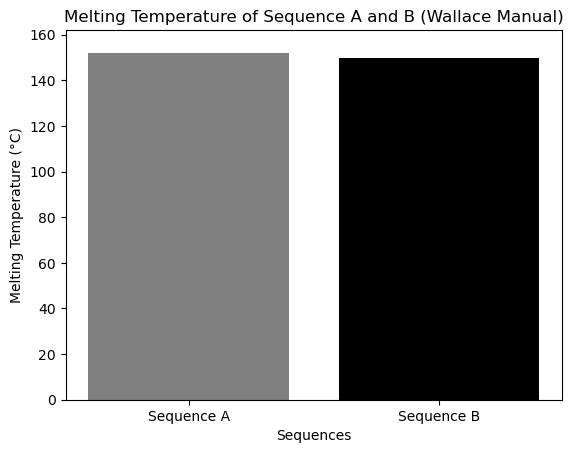

In [ ]:
# 2. refer to wallace rule to calculate the melting point of sequence A and B, and plot them using matplotlib library
import matplotlib.pyplot as plt

tm_seqA_wallace = MeltingTemp.Tm_Wallace(seqA)
print(f"Melting Temperature (Wallace): {tm_seqA_wallace} °C")

tm_seqB_wallace = MeltingTemp.Tm_Wallace(seqB)
print(f"Melting Temperature (Wallace): {tm_seqB_wallace} °C")

sequences = ['Sequence A', 'Sequence B']
melting_points = [tm_seqA_wallace, tm_seqB_wallace]


# Plotting the melting points
plt.bar(sequences, melting_points, color=['gray', 'black'])
plt.xlabel('Sequences')
plt.ylabel('Melting Temperature (°C)')
plt.title('Melting Temperature of Sequence A and B (Wallace Manual)')
plt.ylim(0, max(melting_points) + 10)
plt.show()


In [ ]:
# 3. Calculate the GC Content of sequence A and sequence B
gc_seqA = gc_fraction(seqA)
gc_seqB = gc_fraction(seqB)

print(f"GC Content of Sequence A: {gc_seqA*100}%")
print(f"GC Content of Sequence B: {gc_seqB*100}%")

GC Content of Sequence A: 58.333333333333336%
GC Content of Sequence B: 56.25%


In [ ]:
# 4. Calculate the AT Content of sequence A and sequence B
at_seqA = 1 - gc_seqA
at_seqB = 1 - gc_seqB

print(f"AT Content of Sequence A: {at_seqA*100}%")
print(f"AT Content of Sequence B: {at_seqB*100}%")

AT Content of Sequence A: 41.666666666666664%
AT Content of Sequence B: 43.75%


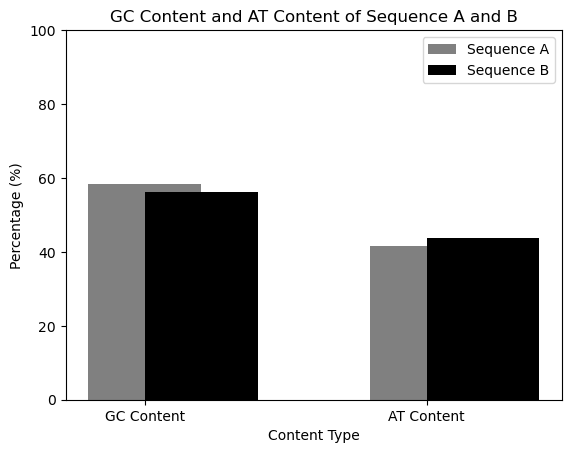

In [ ]:
# 5. Plot the GC Content and AT Content of sequence A and sequence B using matplotlib library
labels = ['GC Content', 'AT Content']

seqA_values = [gc_seqA*100, at_seqA*100]
seqB_values = [gc_seqB*100, at_seqB*100]

x = range(len(labels))
plt.bar(x, seqA_values, width=0.4, label='Sequence A', color='gray', align='center')
plt.bar(x, seqB_values, width=0.4, label='Sequence B', color='black', align='edge')

plt.xlabel('Content Type')
plt.ylabel('Percentage (%)')
plt.title('GC Content and AT Content of Sequence A and B')
plt.xticks(x, labels)
plt.legend()
plt.ylim(0, 100)
plt.show()